1. Discretization (Binning):Discretization (or Binning) is the process of converting continuous numerical data into intervals (bins or groups).

Why do we use it?
To simplify data.
To reduce the effect of outliers.
Some machine learning algorithms perform better with grouped data.

Where is it used?
Age groups
Salary ranges
Temperature ranges
Customer segmentation

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
import kagglehub

path = kagglehub.dataset_download("hesh97/titanicdataset-traincsv")

print(path)

C:\Users\Dir com\.cache\kagglehub\datasets\hesh97\titanicdataset-traincsv\versions\1


In [4]:
import os
# Import the required libraries before using them
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df = df[['Age', 'Fare', 'Survived']]

df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [6]:
df.dropna(inplace= True)

In [7]:
df.shape

(714, 3)

In [8]:
x = df[['Age', 'Fare']]   # DataFrame (2D)
y = df['Survived']        # Series (1D)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [11]:
clf = DecisionTreeClassifier()

In [12]:
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

In [13]:
accuracy_score(y_test , y_pred)

0.6363636363636364

In [14]:
np.mean(
    cross_val_score(
        DecisionTreeClassifier(),
        x,y,cv=10,scoring='accuracy'
)
)

np.float64(0.6316901408450704)

In [21]:
k_age = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile',
    quantile_method='averaged_inverted_cdf'
)

k_fare = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile',
    quantile_method='averaged_inverted_cdf'
)

In [22]:
trf = ColumnTransformer([
    ('first', k_age, [0]),
    ('second', k_fare, [1])
])

In [23]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [29]:
trf.named_transformers_['first'].n_bins_

array([10])

In [28]:
trf.named_transformers_['second'].n_bins_

array([10])

In [30]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [32]:
output = pd.DataFrame({
    'age': x_train['Age'].reset_index(drop=True),
    'age_trf': x_train_trf[:, 0],
    'fare': x_train['Fare'].reset_index(drop=True),
    'fare_trf': x_train_trf[:, 1]
})

In [34]:
output['age_labels'] = pd.cut(
    x=x_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)

output['fare_labels'] = pd.cut(
    x=x_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)

In [35]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
469,22.0,3.0,9.8375,3.0,"(0.42, 14.0]","(15.75, 26.0]"
557,22.0,3.0,8.0500,2.0,NaN,NaN
282,32.0,6.0,7.9250,2.0,NaN,NaN
372,14.0,1.0,120.0000,9.0,"(14.0, 19.0]","(7.896, 9.225]"
270,36.0,7.0,13.0000,4.0,NaN,NaN


In [36]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf , y_train)
y_pred2 = clf.predict(x_test_trf)

In [37]:
accuracy_score(y_test , y_pred2)

0.6223776223776224

In [38]:
x_trf = trf.fit_transform(x)

np.mean(
    cross_val_score(
        DecisionTreeClassifier(),
        x,y,cv=10,scoring='accuracy'
)
)

np.float64(0.635935054773083)

In [45]:
def discretize(bins, strategy):

    k_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy,
        quantile_method='averaged_inverted_cdf'
    )

    k_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy,
        quantile_method='averaged_inverted_cdf'
    )

    trf = ColumnTransformer([
        ('age', k_age, [0]),
        ('fare', k_fare, [1])
    ])

    x_trf = trf.fit_transform(x)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(random_state=42),
                x_trf,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    plt.figure(figsize=(14, 8))

    # Age Before
    plt.subplot(221)
    plt.hist(x['Age'])
    plt.title('Age - Before')

    # Age After
    plt.subplot(222)
    plt.hist(x_trf[:, 0], color='red')
    plt.title('Age - After')

    # Fare Before
    plt.subplot(223)
    plt.hist(x['Fare'])
    plt.title('Fare - Before')

    # Fare After
    plt.subplot(224)
    plt.hist(x_trf[:, 1], color='green')
    plt.title('Fare - After')

    plt.tight_layout()
    plt.show()

0.6807316118935838


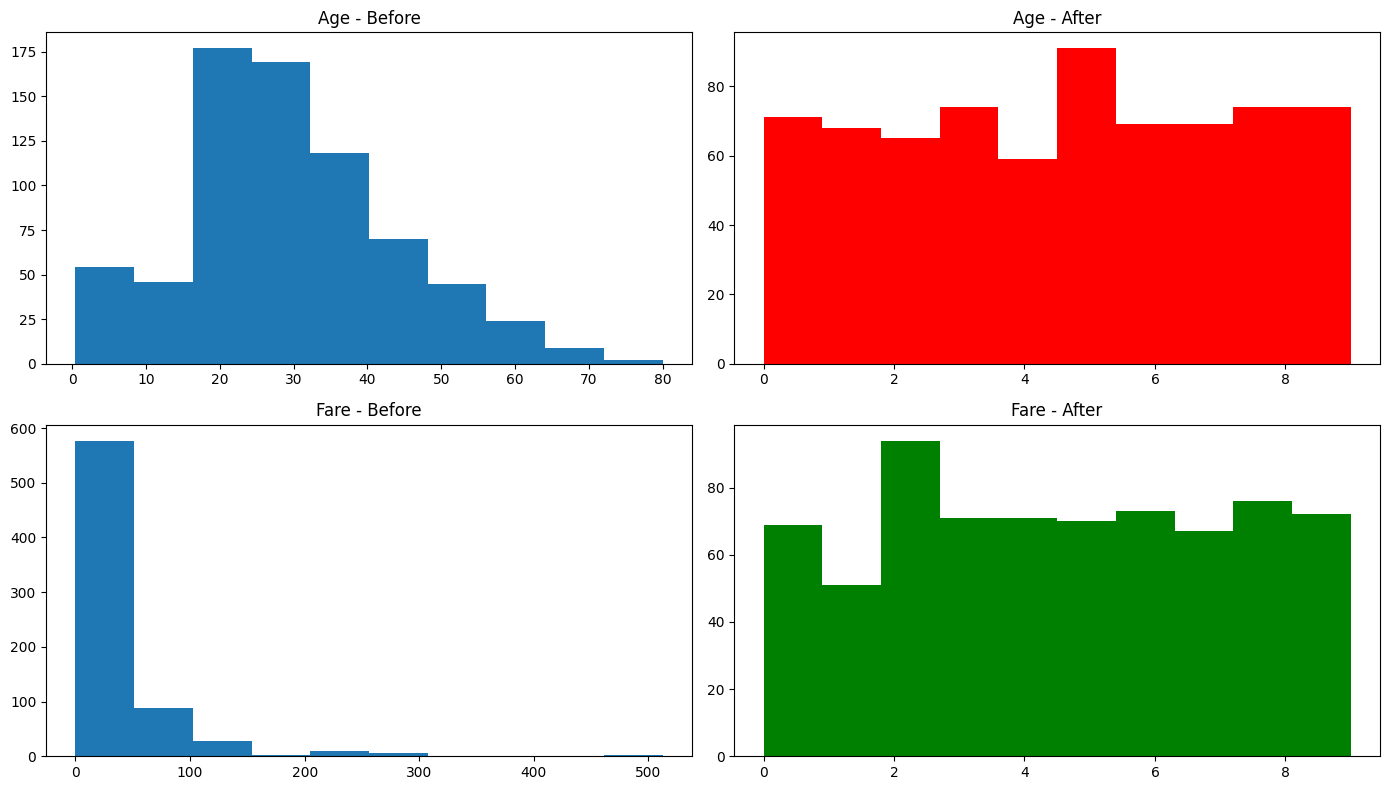

In [46]:
discretize(10, 'quantile')

0.6864632237871675


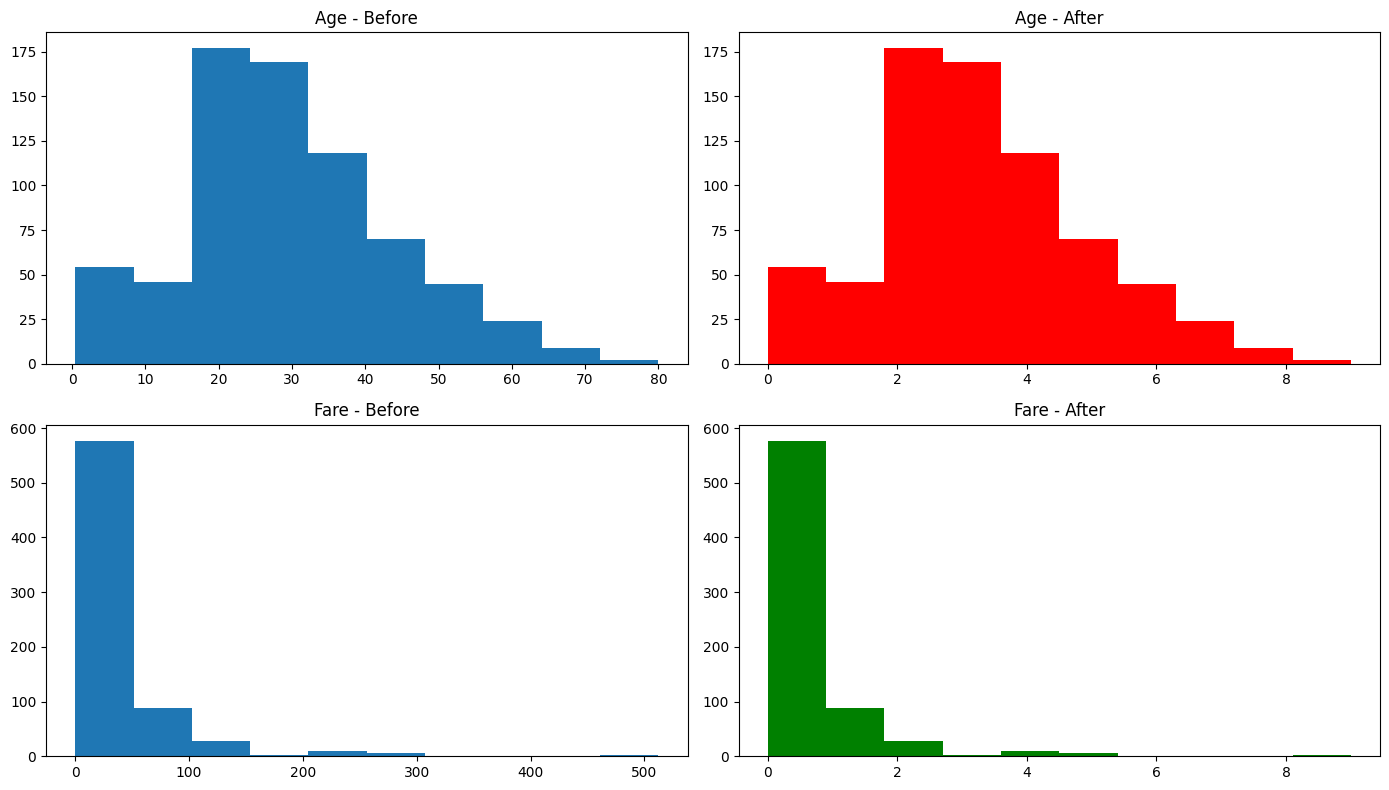

In [47]:
discretize(10, 'uniform')